# Modelado Estocástico
## VECM


### Ejemplo II.5.10 de Carol Alexander: Cointegración en tasa de interes de UK, Metodología: Tests de Johansen (traza y máximo autovalor)

In [ ]:
!pip install arch

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import DFGLS
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
import matplotlib.dates as mdates

Leo los datos y los acondiciono para su análisis

In [ ]:
df = pd.read_excel("UK_rates.xlsx").dropna()

meses = {
    "ene": "Jan", "feb": "Feb", "mar": "Mar", "abr": "Apr", "may": "May", "jun": "Jun",
    "jul": "Jul", "ago": "Aug", "sep": "Sep", "oct": "Oct", "nov": "Nov", "dic": "Dec"}
df['dates'] = df['dates'].replace(meses, regex=True)
df['dates'] = pd.to_datetime(df['dates'], format="%d %b %y", dayfirst=True, errors='coerce')
df

,dates,mth1,mth2,mth3,mth4,mth5,mth6,mth7,mth8,mth9,mth10,mth11,mth12
0,2000-01-04,5.51,5.67,5.78,5.86,5.94,6.02,6.08,6.14,6.20,6.24,6.29,6.32
1,2000-01-05,5.52,5.68,5.77,5.86,5.94,6.01,6.08,6.15,6.20,6.25,6.30,6.33
2,2000-01-06,5.52,5.68,5.77,5.86,5.93,6.01,6.08,6.14,6.20,6.25,6.29,6.33
3,2000-01-07,5.56,5.68,5.76,5.83,5.91,5.98,6.05,6.11,6.17,6.22,6.26,6.30
4,2000-01-10,5.56,5.68,5.76,5.83,5.91,5.98,6.05,6.11,6.16,6.20,6.24,6.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1895,2007-07-09,5.79,5.81,5.83,5.84,5.85,5.85,5.85,5.85,5.84,5.84,5.84,5.83
1896,2007-07-10,5.79,5.81,5.82,5.82,5.83,5.82,5.82,5.82,5.81,5.80,5.80,5.79
1897,2007-07-11,5.79,5.80,5.82,5.82,5.82,5.82,5.82,5.81,5.81,5.80,5.79,5.79
1898,2007-07-12,5.79,5.81,5.82,5.83,5.83,5.83,5.82,5.82,5.81,5.81,5.80,5.79


Gráfico de los datos para los meses indicados

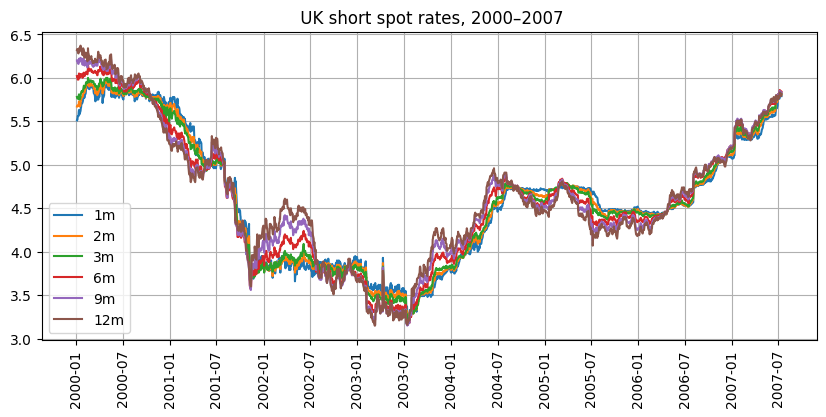

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df['dates'],df["mth1"], label="1m")
plt.plot(df['dates'],df["mth2"], label="2m")
plt.plot(df['dates'],df["mth3"], label="3m")
plt.plot(df['dates'],df["mth6"], label="6m")
plt.plot(df['dates'],df["mth9"], label="9m")
plt.plot(df['dates'],df["mth12"], label="12m")

plt.title(" UK short spot rates, 2000–2007")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator([1,7]))
plt.xticks(rotation=90)
plt.show()

Guardo el subconjunto de meses deseado

In [ ]:
rates = df[['mth1', 'mth2', 'mth3', 'mth6', 'mth9', 'mth12']]
rates

,mth1,mth2,mth3,mth6,mth9,mth12
0,5.51,5.67,5.78,6.02,6.20,6.32
1,5.52,5.68,5.77,6.01,6.20,6.33
2,5.52,5.68,5.77,6.01,6.20,6.33
3,5.56,5.68,5.76,5.98,6.17,6.30
4,5.56,5.68,5.76,5.98,6.16,6.28
...,...,...,...,...,...,...
1895,5.79,5.81,5.83,5.85,5.84,5.83
1896,5.79,5.81,5.82,5.82,5.81,5.79
1897,5.79,5.80,5.82,5.82,5.81,5.79
1898,5.79,5.81,5.82,5.83,5.81,5.79


Corremos ADF con constante y tendencia determinística para cada tasa de rendimiento.

Reportamos estadístico, p-value, lags usados y valores críticos 1, 5 y 10%



In [ ]:
# ADF con TD para las series en niveles:
for col in rates.columns:
    serie = rates[col].dropna()
    test = adfuller(serie, regression="ct", autolag="t-stat")
    print(f"{col}:\nestadístico={test[0]}\np-valor={test[1]}\nrezagos={test[2]}\ncrit={test[4]}\n")


mth1:
estadístico=-0.581613577181921
p-valor=0.9798654223307968
rezagos=26
crit={'1%': np.float64(-3.963611599589335), '5%': np.float64(-3.412836629620891), '10%': np.float64(-3.128431581392459)}

mth2:
estadístico=-0.7097426129209137
p-valor=0.9724996692761025
rezagos=26
crit={'1%': np.float64(-3.963611599589335), '5%': np.float64(-3.412836629620891), '10%': np.float64(-3.128431581392459)}

mth3:
estadístico=-0.35070910861682064
p-valor=0.9882678649232775
rezagos=11
crit={'1%': np.float64(-3.9635730693004976), '5%': np.float64(-3.4128179654376094), '10%': np.float64(-3.1284205959735143)}

mth6:
estadístico=-0.9979203358813699
p-valor=0.9443939815421306
rezagos=26
crit={'1%': np.float64(-3.963611599589335), '5%': np.float64(-3.412836629620891), '10%': np.float64(-3.128431581392459)}

mth9:
estadístico=-1.0929745412696106
p-valor=0.9302331009751771
rezagos=20
crit={'1%': np.float64(-3.9635961135292486), '5%': np.float64(-3.412829128149237), '10%': np.float64(-3.1284271661606464)}

mth12

Corremos la regresión por detras para cada ADF generado previamente. Vemos que la tendencia determinística es estadísticamente significativa.


In [ ]:
def ADF_con_detalle(nombre_columna, datos):
  y = datos.dropna().astype(float)
  # Corremos el ADF con el criterio "t-stat" y guardamos sus resultados
  adf_stat, pval, k_lags, nobs, crit, icbest = adfuller(
      y, regression="ct", autolag="t-stat"
  )
  print(f"\n================  {nombre_columna}  ================")
  print(f"ADF stat = {adf_stat:.4f} | p-val = {pval:.4f} | lags = {k_lags} | nobs = {nobs}")

  # Si la serie es muy corta para esos lags, reducimos k_lags
  k = min(k_lags, max(0, len(y) - 5))

  # Construcción de la regresión ADF: Δy_t ~ const + trend + y_{t-1} + Σ Δy_{t-i}
  T = len(y)
  t = pd.Series(np.arange(1, T + 1), index=y.index, name="trend")
  dy = y.diff()

  X = pd.DataFrame({"const": 1.0, "trend": t, "y_lag1": y.shift(1)}, index=y.index)
  for i in range(1, k + 1):
      X[f"dy_lag{i}"] = dy.shift(i)

  Y = dy

  # Alinear y ajustar OLS
  data = pd.concat([Y, X], axis=1).dropna()
  Y_ols = data.iloc[:, 0]      # Δy_t
  X_ols = data.iloc[:, 1:]     # const, trend, y_lag1, dy_lag1..k

  res = sm.OLS(Y_ols, X_ols).fit()
  print(res.summary())

Para visualizarlo mes a mes

In [ ]:
for col in rates.columns:
    ADF_con_detalle(col, rates[col])


================  mth1  ================
ADF stat = -0.5816 | p-val = 0.9799 | lags = 26 | nobs = 1873
                            OLS Regression Results                            
Dep. Variable:                   mth1   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     5.893
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           2.73e-20
Time:                        11:09:48   Log-Likelihood:                 3715.8
No. Observations:                1873   AIC:                            -7374.
Df Residuals:                    1844   BIC:                            -7213.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

Hacemos los mismo para las primeras diferencias de cada tasa de rendimiento.

Los tests sugieren que las tasas son I(1). La especificación con constante y tendencia resulta relevante en los tests considerados, aunque la significancia de los términos determinísticos no debe confundirse con el orden de integración.

In [ ]:
for col in rates.columns:
  ADF_con_detalle(col, rates[col].diff())


================  mth1  ================
ADF stat = -8.0481 | p-val = 0.0000 | lags = 25 | nobs = 1873
                            OLS Regression Results                            
Dep. Variable:                   mth1   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     113.1
Date:                Sat, 22 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:09:54   Log-Likelihood:                 3715.7
No. Observations:                1873   AIC:                            -7375.
Df Residuals:                    1845   BIC:                            -7220.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

Aplicamos el test DFGLS (Elliott-Rothenberg-Stock test) para testear por raices unitarias cada tasa. Con constante y tendencia determinística. Simplemente como para reforzar lo encontrado con el ADF.

In [ ]:
for mes in rates:
    test = DFGLS(rates[mes].dropna(), trend="ct")
    print(f"{mes}:\nestadístico: {test.stat}\npvalue: {test.pvalue}\n")

mth1:
estadístico: 0.05412839169546421
pvalue: 0.9964971867219977

mth2:
estadístico: 0.05339930915866517
pvalue: 0.9964842640995767

mth3:
estadístico: 0.3010229451612089
pvalue: 0.9990771200038097

mth6:
estadístico: 0.3688665222775641
pvalue: 0.9993795966169035

mth9:
estadístico: 0.26592785721768225
pvalue: 0.9988725391376966

mth12:
estadístico: 0.08748064501320937
pvalue: 0.9970449670739032



DFGLS también a las diferencias. Con constante y tendencia determinística

($x_t - x_{t-1}$)

In [ ]:
for mes in rates:
    test = DFGLS(rates[mes].diff().dropna(), trend="ct")
    print(f"{mes}\nestadístico: {test.stat}\npvalue: {test.pvalue}\n")

mth1
estadístico: -5.785977553182089
pvalue: 8.086221025092628e-07

mth2
estadístico: -31.778832352191486
pvalue: 0.0

mth3
estadístico: -52.458263272795435
pvalue: 0.0

mth6
estadístico: -47.60680642375179
pvalue: 0.0

mth9
estadístico: -44.03370705171813
pvalue: 0.0

mth12
estadístico: -39.992693609947885
pvalue: 0.0



### Criterio de seleccion de rezagos (lags): usamos "var_model.select_order" como en los VAR

In [ ]:
var_model = VAR(rates)
lag_order_results = var_model.select_order(maxlags=12)
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -38.58      -38.56   1.762e-17      -38.57
1       -53.10      -52.98   8.650e-24      -53.06
2       -53.54     -53.31*   5.616e-24      -53.45
3       -53.62      -53.29   5.150e-24      -53.50
4       -53.67      -53.23   4.932e-24     -53.50*
5      -53.67*      -53.13  4.908e-24*      -53.47
6       -53.66      -53.01   4.963e-24      -53.42
7       -53.65      -52.89   5.021e-24      -53.37
8       -53.64      -52.78   5.055e-24      -53.32
9       -53.63      -52.66   5.099e-24      -53.28
10      -53.62      -52.55   5.149e-24      -53.23
11      -53.62      -52.44   5.175e-24      -53.18
12      -53.61      -52.32   5.237e-24      -53.13
--------------------------------------------------


### Test de traza de Johansen

Vamos a utilizar `coint_johansen` de `statsmodels.tsa.vector_ar.vecm` para realizar el test de traza de Johansen.
Sus parámetros son:
```
det_order : int
        * -1 - no deterministic terms
        * 0 - constant term
        * 1 - linear trend
    k_ar_diff : int, nonnegative
        Number of lagged differences in the model.
```

Siguiendo AIC arriba, seleccionamos  5 rezagos (lags), pero en el VECM debemos restarle 1 al valor donde aparece el asterisco según el criterio que elijamos arriba.

Si el VAR order selection indica "p" lags, al correr el test de Johansen debemos indicar "p-1" lags. Esto se debe a que VAR order selection indica la cantidad de lags para un VAR en niveles, y un VAR(p) en niveles puede reescribirse como un VECM(p-1) (es decir, en primeras diferencias).

Un VECM siempre se especifica en las primeras diferencias de las variables endógenas (integradas de orden 1 en niveles como se mostró con los ADF/DFGLS arriba).

Por ejemplo, AIC acaba de indicarnos 5 lags, entonces ahora usamos k_ar_diff = 4.



In [ ]:
jres = coint_johansen(rates, det_order=1, k_ar_diff=4)

n = rates.shape[1]
hyp = [f"At most {i}" for i in range (n)]
hyp[0] = "None"

pd.DataFrame({
    "Hypothesis": hyp,
    "Eigenvalue": jres.eig[:n],
    "Trace Statistic": jres.lr1[:n],
    "5% Critical Value": jres.cvt[:n, 1],
    "1% Critical Value": jres.cvt[:n, 2]
})

,Hypothesis,Eigenvalue,Trace Statistic,5% Critical Value,1% Critical Value
0,None,0.114437,509.384514,107.3429,116.9829
1,At most 1,0.073286,279.081336,79.3422,87.7748
2,At most 2,0.036685,134.852708,55.2459,62.5202
3,At most 3,0.023112,64.026742,35.0116,41.0815
4,At most 4,0.009296,19.715097,18.3985,23.1485
5,At most 5,0.001063,2.016262,3.8415,6.6349


Si encuentro que hay al menos una relación de cointegracion, estimo el VECM. En la tabla anterior, si rechazamos H0 en una fila seguimos a la siguiente fila. Se rechaza si el Trace Statistic > Critical Value. Cuando no rechazamos en una fila, ese es el rango de la matriz PI y esa es la cantidad de relaciones de cointegración que tenemos. Por ejemplo, si usamos 1% Critical Value, encontramos 4 relaciones de cointegración (o sea, 4 combinaciones lineales de las 6 variables tales que son I(0) ).

In [ ]:
# k_ar_diff = número de rezagos en diferencias que querés en el VECM
# En el test de Johansen, aclaramos el valor de k_ar_diff
jres = coint_johansen(rates, det_order=1, k_ar_diff=4)

# Calcular el rango
rank = sum(jres.lr1 > jres.cvt[:, 2])
print("Cointegration rank:", rank)

Cointegration rank: 4


ESTIMACION DEL VECM: Statsmodels no te arma una “sola tabla de regresión por ecuación” con los ce’s y Δ-lags mezclados. Los separa. Esto es exclusivamente cómo presenta los resultados Statsmodels.


Opciones de `deterministic`:

- `"nc"` → no hay constante ni tendencia determinística lineal
- `"ci"` → hay constante en las ecuaciones de cointegración (constant in)
- `"co"` → constante en el modelo de corto plazo (constant out)
- `"li"` → tendencia determinística lineal en las ecuaciones de cointegración (linear trend in)
- `"lo"` → tendencia determinística lineal en el modelo de corto plazo (linear trend out)


Otros parámetros:

- `exog_coint` agrega regresores determinísticos que van dentro de la ecuación de cointegración (relación de largo plazo).

- `exog` agrega regresores determinísticos al modelo de corto plazo (fuera de la relación de cointegración).

In [ ]:
vecm = VECM(rates, k_ar_diff=4, coint_rank=rank, deterministic="colo")
vecm_res = vecm.fit()
print(vecm_res.summary())


Det. terms outside the coint. relation & lagged endog. parameters for equation mth1
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0129      0.004      3.059      0.002       0.005       0.021
lin_trend  -6.434e-07   1.57e-06     -0.410      0.682   -3.72e-06    2.43e-06
L1.mth1        0.1926      0.072      2.681      0.007       0.052       0.333
L1.mth2       -1.0699      0.225     -4.760      0.000      -1.510      -0.629
L1.mth3        0.6620      0.259      2.559      0.011       0.155       1.169
L1.mth6        0.0482      0.237      0.203      0.839      -0.416       0.512
L1.mth9       -0.3227      0.256     -1.260      0.208      -0.825       0.179
L1.mth12       0.2283      0.133      1.712      0.087      -0.033       0.490
L2.mth1        0.1582      0.069      2.283      0.022       0.022       0.294
L2.mth2       -0.6143      0.215     -2.862    

El resultado es de la Clase `VECMResults`, que incluye varios atributos:

Dentro de la relación de cointegración:

- `const_coint -> ndarray`: Si hay un término determinístico constante dentro de la relación de cointegración, este es la primera fila de det_coef_coint. Si no, un array de ceros.

- `det_coef_coint -> ndarray`: Matriz de coeficientes estimados para todos los términos determinísticos incluidos en la relación de cointegración.

- `lin_trend_coint -> ndarray`: Si hay una tendencia lineal determinística dentro de la relación de cointegración, contiene los coeficientes estimados correspondientes. Si no, un array de ceros.

- `exog_coint_coefs -> ndarray o None`: Si se pasaron términos determinísticos dentro de la relación de cointegración a través del parámetro `exog_coint`, este atributo contiene los coeficientes estimados correspondientes. Representa las últimas filas de `det_coef_coint`. Si no se pasaron, es `None`.

Fuera de la relación de cointegración:

- `det_coef -> ndarray`: Coeficientes estimados para todos los términos determinísticos fuera de la relación de cointegración.

- `const -> ndarray`: Si se especifica un término determinístico constante fuera de la cointegración, este es la primera columna de `det_coef`. Si no, es un array de tamaño cero.

- `seasonal -> ndarray`: Si el parámetro `seasons` es > 0, contiene los coeficientes estimados correspondientes a los términos estacionales. Si no, es un array de tamaño cero.

- `lin_trend -> ndarray`: Si se especifica un término determinístico de tendencia lineal fuera de la cointegración, contiene los coeficientes estimados correspondientes. Si no, es un array de tamaño cero.

- `exog_coefs -> ndarray`: Si se pasaron términos determinísticos fuera de la relación de cointegración a través del parámetro `exog`, contiene los coeficientes estimados correspondientes. Representa las últimas columnas de `det_coef`. Si no se pasaron términos `exog`, es un array de tamaño cero.


https://www.statsmodels.org/dev/generated/statsmodels.tsa.vector_ar.vecm.VECMResults.html

### Tests de Diagnostico
Autocorrelación

Fabrico un df con los residuos

In [ ]:
resid = pd.DataFrame(vecm_res.resid, columns=rates.columns)
resid

,mth1,mth2,mth3,mth6,mth9,mth12
0,0.018394,0.003735,0.020199,0.039931,0.044045,0.042403
1,0.005238,0.013225,0.016280,0.035607,0.028347,0.028819
2,-0.059600,-0.051910,-0.042237,-0.016767,-0.009439,-0.017392
3,-0.020397,-0.025486,-0.029542,-0.010436,-0.002396,0.004442
4,0.012040,-0.005891,0.001218,0.015982,0.033745,0.050591
...,...,...,...,...,...,...
1890,0.008320,-0.000886,-0.000872,-0.006949,-0.013069,-0.003529
1891,-0.001806,-0.006456,-0.015247,-0.037916,-0.042747,-0.047000
1892,-0.001327,-0.011346,-0.002400,-0.005789,-0.002183,-0.000966
1893,-0.002964,0.001094,-0.001737,0.002608,-0.006103,-0.005806


Ejemplo para 12 lags

In [ ]:
for col in resid.columns:
    lb = acorr_ljungbox(resid[col], lags=[12], return_df=True)
    print(f"\nLjung-Box para residuos de {col} (lag 12):\n{lb}")


Ljung-Box para residuos de mth1 (lag 12):
      lb_stat  lb_pvalue
12  12.178526   0.431451

Ljung-Box para residuos de mth2 (lag 12):
     lb_stat  lb_pvalue
12  6.810337   0.869888

Ljung-Box para residuos de mth3 (lag 12):
     lb_stat  lb_pvalue
12  8.836872   0.716797

Ljung-Box para residuos de mth6 (lag 12):
     lb_stat  lb_pvalue
12  8.546914   0.741065

Ljung-Box para residuos de mth9 (lag 12):
     lb_stat  lb_pvalue
12  6.300335   0.900192

Ljung-Box para residuos de mth12 (lag 12):
     lb_stat  lb_pvalue
12  6.429505   0.892903


Normalidad

In [ ]:
for i, col in enumerate(rates.columns):
    jb = jarque_bera(vecm_res.resid[:,i])
    print(f"{col}\n {jb} \n")

mth1
 SignificanceResult(statistic=np.float64(24602.50726640202), pvalue=np.float64(0.0)) 

mth2
 SignificanceResult(statistic=np.float64(75573.98949267827), pvalue=np.float64(0.0)) 

mth3
 SignificanceResult(statistic=np.float64(127420.8637183227), pvalue=np.float64(0.0)) 

mth6
 SignificanceResult(statistic=np.float64(245825.45783232787), pvalue=np.float64(0.0)) 

mth9
 SignificanceResult(statistic=np.float64(161692.7343750825), pvalue=np.float64(0.0)) 

mth12
 SignificanceResult(statistic=np.float64(36265.18384870615), pvalue=np.float64(0.0)) 



Matrices $\alpha$ y $\beta$

In [ ]:
print("\nAlpha (ajuste):\n", vecm_res.alpha)
print("\nBeta (vectores cointegrantes):\n", vecm_res.beta)
print("\nPi (alpha * beta'):\n", vecm_res.alpha @ vecm_res.beta.T)


Alpha (ajuste):
 [[-0.43257021  0.93023611 -0.61791963  0.15799677]
 [-0.08854227  0.07095771 -0.02546648  0.03621513]
 [-0.08338155  0.31511538 -0.44413101  0.38277797]
 [-0.01711249  0.04377879 -0.057199   -0.03540656]
 [-0.02502951  0.11605551 -0.17506125  0.16402739]
 [-0.00605003 -0.03322748  0.06158288 -0.06963734]]

Beta (vectores cointegrantes):
 [[ 1.00000000e+00  7.15721437e-16  5.02214166e-16  3.25226186e-17]
 [-1.41681594e-15  1.00000000e+00 -1.23928455e-15 -1.07350018e-16]
 [ 2.04750655e-16 -1.34880870e-16  1.00000000e+00  2.31249613e-18]
 [-7.72787036e-16 -3.29239571e-16 -8.73118940e-17  1.00000000e+00]
 [-3.41125335e+00 -3.21709827e+00 -2.99093171e+00 -2.08381595e+00]
 [ 2.48113105e+00  2.27328723e+00  2.03397737e+00  1.09762462e+00]]

Pi (alpha * beta'):
 [[-0.43257021  0.93023611 -0.61791963  0.15799677  0.00186479 -0.04198288]
 [-0.08854227  0.07095771 -0.02546648  0.03621513  0.07446502 -0.07042534]
 [-0.08338155  0.31511538 -0.44413101  0.38277797 -0.19859486  0.02